In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Telco customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove missing values
data = data.dropna(subset=["TotalCharges"]).copy()

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

display(data.head())

Dataset loaded successfully!
Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
segmentation_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_seg = data[segmentation_features].copy()

scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

data["Cluster"] = kmeans.fit_predict(X_seg_scaled)

print("Customer segmentation completed!")
print(data["Cluster"].value_counts())

Customer segmentation completed!
Cluster
1    4672
0    2360
Name: count, dtype: int64


In [4]:
cluster_means = data.groupby("Cluster")[segmentation_features].mean()

high_value_cluster = cluster_means["TotalCharges"].idxmax()
low_value_cluster = cluster_means["TotalCharges"].idxmin()

persona_mapping = {
    high_value_cluster: "Loyal High-Value Customers",
    low_value_cluster: "New/Low-Value Customers"
}

data["Persona"] = data["Cluster"].map(persona_mapping)

print("Personas assigned successfully!")

Personas assigned successfully!


In [5]:
persona_summary = data.groupby("Persona")[segmentation_features].mean().round(2)

persona_summary["Customer Count"] = data["Persona"].value_counts()

display(persona_summary)

,tenure,MonthlyCharges,TotalCharges,Customer Count
Persona,,,,
Loyal High-Value Customers,56.87,89.76,5084.99,2360
New/Low-Value Customers,20.07,52.19,868.07,4672


In [6]:
similarity_scaler = StandardScaler()

X_similarity = similarity_scaler.fit_transform(
    data[segmentation_features]
)

similarity_matrix = cosine_similarity(X_similarity)

def recommend_similar_customers(customer_position, top_n=5):
    scores = similarity_matrix[customer_position]

    similar_positions = np.argsort(scores)[::-1]
    similar_positions = similar_positions[
        similar_positions != customer_position
    ][:top_n]

    result = data.iloc[similar_positions][
        ["customerID", "Persona", "tenure",
         "MonthlyCharges", "TotalCharges"]
    ].copy()

    result["Similarity Score"] = scores[similar_positions]

    return result

recommendations = recommend_similar_customers(0, top_n=5)

display(recommendations)

,customerID,Persona,tenure,MonthlyCharges,TotalCharges,Similarity Score
3902,5999-LCXAO,New/Low-Value Customers,1,29.90,29.90,1.000000
180,6317-YPKDH,New/Low-Value Customers,1,29.95,29.95,0.999999
6080,9526-BIHHD,New/Low-Value Customers,1,29.70,29.70,0.999998
27,8665-UTDHZ,New/Low-Value Customers,1,30.20,30.20,0.999989
3043,3677-IYRBF,New/Low-Value Customers,2,30.40,78.65,0.999974


In [7]:
anomaly_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_anomaly = data[anomaly_features].copy()

scaler_anomaly = StandardScaler()
X_anomaly_scaled = scaler_anomaly.fit_transform(X_anomaly)

isolation_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data["Anomaly"] = isolation_model.fit_predict(X_anomaly_scaled)

data["Anomaly Status"] = data["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Anomaly detection completed!")
print(data["Anomaly Status"].value_counts())

Anomaly detection completed!
Anomaly Status
Normal     6680
Anomaly     352
Name: count, dtype: int64


In [8]:
integrated_summary = data[
    [
        "customerID",
        "Persona",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Anomaly Status"
    ]
].copy()

display(integrated_summary.head(10))

,customerID,Persona,tenure,MonthlyCharges,TotalCharges,Anomaly Status
0,7590-VHVEG,New/Low-Value Customers,1,29.85,29.85,Normal
1,5575-GNVDE,New/Low-Value Customers,34,56.95,1889.50,Normal
2,3668-QPYBK,New/Low-Value Customers,2,53.85,108.15,Normal
3,7795-CFOCW,New/Low-Value Customers,45,42.30,1840.75,Normal
4,9237-HQITU,New/Low-Value Customers,2,70.70,151.65,Normal
5,9305-CDSKC,New/Low-Value Customers,8,99.65,820.50,Normal
6,1452-KIOVK,New/Low-Value Customers,22,89.10,1949.40,Normal
7,6713-OKOMC,New/Low-Value Customers,10,29.75,301.90,Normal
8,7892-POOKP,Loyal High-Value Customers,28,104.80,3046.05,Normal
9,6388-TABGU,Loyal High-Value Customers,62,56.15,3487.95,Normal


In [9]:
overview = {
    "Total Customers": len(data),
    "Loyal High-Value Customers": (
        data["Persona"] == "Loyal High-Value Customers"
    ).sum(),
    "New/Low-Value Customers": (
        data["Persona"] == "New/Low-Value Customers"
    ).sum(),
    "Anomalous Customers": (
        data["Anomaly Status"] == "Anomaly"
    ).sum()
}

overview_df = pd.DataFrame(
    list(overview.items()),
    columns=["Metric", "Value"]
)

display(overview_df)

,Metric,Value
0,Total Customers,7032
1,Loyal High-Value Customers,2360
2,New/Low-Value Customers,4672
3,Anomalous Customers,352


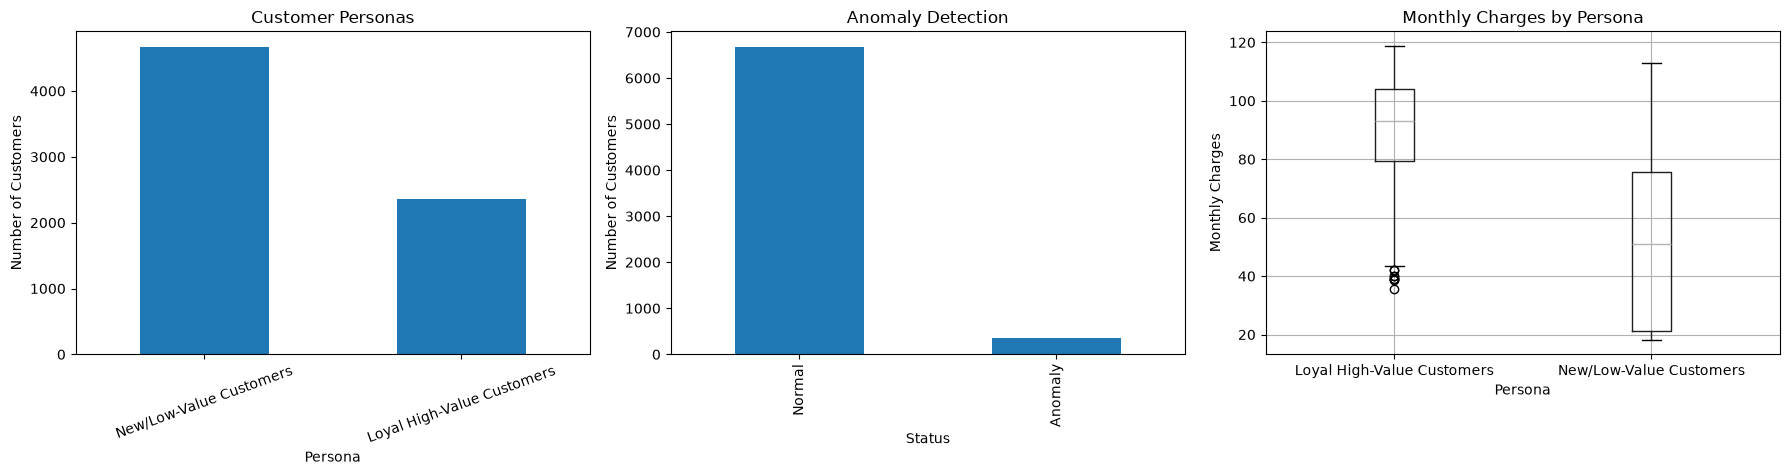

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Customer personas
data["Persona"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Customer Personas")
axes[0].set_xlabel("Persona")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=20)

# 2. Anomaly status
data["Anomaly Status"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Anomaly Detection")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Number of Customers")

# 3. Monthly charges by persona
data.boxplot(
    column="MonthlyCharges",
    by="Persona",
    ax=axes[2]
)
axes[2].set_title("Monthly Charges by Persona")
axes[2].set_xlabel("Persona")
axes[2].set_ylabel("Monthly Charges")
plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "week5_unified_analytics_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
high_value_count = (
    data["Persona"] == "Loyal High-Value Customers"
).sum()

new_customer_count = (
    data["Persona"] == "New/Low-Value Customers"
).sum()

anomaly_count = (
    data["Anomaly Status"] == "Anomaly"
).sum()

insights = f"""
WEEK 5 INTEGRATED ANALYTICS — BUSINESS INSIGHTS

1. Total customers analyzed: {len(data)}

2. Loyal High-Value Customers: {high_value_count}

3. New/Low-Value Customers: {new_customer_count}

4. Anomalous customers detected: {anomaly_count}

5. Customer segmentation helps identify different customer groups.

6. Similarity-based recommendations can support personalized
   service recommendations.

7. Anomaly detection helps identify unusual customer patterns
   that may require further investigation.

8. The unified dashboard brings segmentation, recommendations,
   and anomaly detection into one decision-support workflow.
"""

print(insights)

with open("week5_integrated_business_insights.txt", "w") as file:
    file.write(insights)


WEEK 5 INTEGRATED ANALYTICS — BUSINESS INSIGHTS

1. Total customers analyzed: 7032

2. Loyal High-Value Customers: 2360

3. New/Low-Value Customers: 4672

4. Anomalous customers detected: 352

5. Customer segmentation helps identify different customer groups.

6. Similarity-based recommendations can support personalized
   service recommendations.

7. Anomaly detection helps identify unusual customer patterns
   that may require further investigation.

8. The unified dashboard brings segmentation, recommendations,
   and anomaly detection into one decision-support workflow.



In [12]:
data.to_csv(
    "week5_integrated_customer_analytics.csv",
    index=False
)

print("Integrated analytics dataset saved successfully!")
print("File: week5_integrated_customer_analytics.csv")

Integrated analytics dataset saved successfully!
File: week5_integrated_customer_analytics.csv


In [13]:
from IPython.display import Image, display

print("""
WEEK 5 INTEGRATED ANALYTICS WORKFLOW

                 Telco Customer Dataset
                          |
                          v
                 Data Preparation
                          |
          +---------------+---------------+
          |               |               |
          v               v               v
     Segmentation    Recommendation   Anomaly Detection
          |               |               |
          v               v               v
     Customer          Similar          Unusual
      Personas        Customers         Patterns
          |               |               |
          +---------------+---------------+
                          |
                          v
                  Unified Dashboard
                          |
                          v
                  Business Insights
                          |
                          v
                Decision Support
""")


WEEK 5 INTEGRATED ANALYTICS WORKFLOW

                 Telco Customer Dataset
                          |
                          v
                 Data Preparation
                          |
          +---------------+---------------+
          |               |               |
          v               v               v
     Segmentation    Recommendation   Anomaly Detection
          |               |               |
          v               v               v
     Customer          Similar          Unusual
      Personas        Customers         Patterns
          |               |               |
          +---------------+---------------+
                          |
                          v
                  Unified Dashboard
                          |
                          v
                  Business Insights
                          |
                          v
                Decision Support



In [14]:
reflection = """
WEEK 5 SPRINT REFLECTION

This week focused on integrating multiple machine learning
and analytics components into one unified customer analytics
workflow.

Key components integrated:
- Customer segmentation
- Customer persona analysis
- Similarity-based recommendations
- Anomaly detection
- Business intelligence dashboard

Key learning:
The main challenge was making independently developed
analytics modules work together consistently. Reusing common
features and preprocessing steps helped maintain consistency.

Engineering tradeoffs:
- K-Means provides simple and interpretable customer segments,
  but the selected number of clusters affects the results.
- Cosine similarity provides a simple recommendation approach,
  but recommendations depend on the selected customer features.
- Isolation Forest can identify unusual patterns efficiently,
  but an anomaly does not automatically represent fraud or risk.
- A unified dashboard improves decision-making visibility,
  but it adds complexity compared with individual analyses.

Overall, Week 5 transformed separate analytics experiments
into a unified decision-support workflow.
"""

print(reflection)

with open("week5_sprint_reflection.txt", "w") as file:
    file.write(reflection)


WEEK 5 SPRINT REFLECTION

This week focused on integrating multiple machine learning
and analytics components into one unified customer analytics
workflow.

Key components integrated:
- Customer segmentation
- Customer persona analysis
- Similarity-based recommendations
- Anomaly detection
- Business intelligence dashboard

Key learning:
The main challenge was making independently developed
analytics modules work together consistently. Reusing common
features and preprocessing steps helped maintain consistency.

Engineering tradeoffs:
- K-Means provides simple and interpretable customer segments,
  but the selected number of clusters affects the results.
- Cosine similarity provides a simple recommendation approach,
  but recommendations depend on the selected customer features.
- Isolation Forest can identify unusual patterns efficiently,
  but an anomaly does not automatically represent fraud or risk.
- A unified dashboard improves decision-making visibility,
  but it adds complexit

In [15]:
architecture = """
WEEK 5 WORKFLOW ARCHITECTURE

Dataset
   |
   v
Data Preparation
   |
   +--> Customer Segmentation
   |        |
   |        v
   |    Customer Personas
   |
   +--> Similarity Analysis
   |        |
   |        v
   |    Recommendations
   |
   +--> Anomaly Detection
            |
            v
      Unusual Patterns
            |
            +------------+
                         |
                         v
               Unified Dashboard
                         |
                         v
                 Business Insights
                         |
                         v
                  Decision Support
"""

with open("week5_workflow_architecture.txt", "w") as file:
    file.write(architecture)

print("Workflow architecture saved successfully!")

Workflow architecture saved successfully!


In [16]:
print("=" * 60)
print("WEEK 5 INTEGRATED ANALYTICS — FINAL SUMMARY")
print("=" * 60)

print(f"Total Customers Analyzed: {len(data)}")
print(
    "Customer Personas:",
    data["Persona"].nunique()
)
print(
    "Similar-Customer Recommendation System: Integrated"
)
print(
    "Anomaly Detection: Integrated"
)
print(
    "Unified Dashboard: Created"
)

print("\nOutput Files:")
print("- week5_unified_analytics_dashboard.png")
print("- week5_integrated_business_insights.txt")
print("- week5_integrated_customer_analytics.csv")
print("- week5_sprint_reflection.txt")
print("- week5_workflow_architecture.txt")

print("\nWeek 5 integration completed successfully! ✅")

WEEK 5 INTEGRATED ANALYTICS — FINAL SUMMARY
Total Customers Analyzed: 7032
Customer Personas: 2
Similar-Customer Recommendation System: Integrated
Anomaly Detection: Integrated
Unified Dashboard: Created

Output Files:
- week5_unified_analytics_dashboard.png
- week5_integrated_business_insights.txt
- week5_integrated_customer_analytics.csv
- week5_sprint_reflection.txt
- week5_workflow_architecture.txt

Week 5 integration completed successfully! ✅
